# Build the freeway parquets

Generates the two static files the browser loads (see `docs/plan-build-parquets.md`):

- `data/freeways_path.parquet` — one row per freeway/tollway segment: `seg_id`, `path` (`[[lon,lat]...]`), `h3_r5`, `type`, `length_km`.
- `data/freeway_hexes_r5.parquet` — one row per unique res-5 cell: `h3_r5`, `lat`, `lon`, `gefs_i`, `gefs_j`.

Source: Natural Earth `ne_10m_roads_north_america` (EPSG:4326). Filter `type ∈ {Freeway, Tollway}` & `country == United States`. Hazard grid: GEFS 35-day, 0.25° regular lat/lon (v1 caps at lead < 240 h, single index pair).

In [1]:
from pathlib import Path

import geopandas as gpd
import h3
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import shapely

# --- config -------------------------------------------------------------
NE_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_roads_north_america.zip"

# GEFS 35-day grid — published spec, regular lat/lon. lon -180->179.75 @ +0.25,
# lat 90->-90 @ -0.25. The browser reads the zarr per frame; here we only need
# these constants to bake the pixel index (gefs_i/j) per hex. No zarr read.
GRID = dict(lon0=-180.0, lat0=90.0, dlon=0.25, dlat=-0.25, nlon=1440, nlat=721)

RES = 5            # H3 resolution for the hazard-lookup grid
DENSIFY_M = 3000   # densify step (m) so long straightaways don't skip cells
OUT = Path("data")
OUT.mkdir(exist_ok=True)
print("output dir:", OUT.resolve())

output dir: /Users/stephenk/dev/projects/zarr-road-risk/data


## Step 1 — load + filter the roads

In [9]:
gdf = gpd.read_file(NE_URL, engine="pyogrio")
gdf = gdf[gdf["type"].isin(["Freeway", "Tollway"])] # & (gdf["country"] == "United States")]
# one row per LineString
gdf = gdf.explode(index_parts=False).reset_index(drop=True)
gdf = gdf[gdf.geometry.geom_type == "LineString"].reset_index(drop=True)
gdf["seg_id"] = gdf.index.astype("int32")
print(len(gdf), "segments")
gdf[["seg_id", "type", "state", "country"]].head()

3170 segments


,seg_id,type,state,country
0,0,Freeway,Alabama,United States
1,1,Freeway,Alabama,United States
2,2,Freeway,Alabama,United States
3,3,Freeway,Alabama,United States
4,4,Freeway,Alabama,United States


## Step 2 — vertices, per-segment cell, and full-corridor cell set

`path` keeps the original geometry. For cell coverage we densify (project to 5070 m,
segmentize, back to 4326) and map every vertex to a res-5 cell — this captures the
whole corridor without the zero-area-linestring problem (no buffer needed; that
caveat is for the DuckDB polygon polyfill path).

In [10]:
def coords(line):
    return [[float(x), float(y)] for x, y in line.coords]

paths = [coords(g) for g in gdf.geometry]

# representative cell per segment (midpoint vertex) -- note h3 v4 takes (lat, lon)
def rep_cell(p):
    lon, lat = p[len(p) // 2]
    return h3.latlng_to_cell(lat, lon, RES)

gdf["h3_r5"] = [rep_cell(p) for p in paths]

# full corridor: densify in meters, then cells per densified vertex
dense = gpd.GeoSeries(gdf.geometry, crs=4326).to_crs(5070).segmentize(DENSIFY_M).to_crs(4326)
seg_cells = []
for g in dense:
    cs = {h3.latlng_to_cell(lat, lon, RES) for lon, lat in g.coords}
    seg_cells.append(cs)

print("segments:", len(paths))
print("median vertices/path:", int(np.median([len(p) for p in paths])))
print("median cells/segment (corridor):", int(np.median([len(c) for c in seg_cells])))

segments: 3170
median vertices/path: 41
median cells/segment (corridor): 2


## Step 3 — write `freeways_path.parquet`

In [11]:
length_km = gpd.GeoSeries(gdf.geometry, crs=4326).to_crs(5070).length / 1000.0

path_tbl = pa.table({
    "seg_id":    pa.array(gdf["seg_id"].to_numpy(), pa.int32()),
    "path":      pa.array(paths, type=pa.list_(pa.list_(pa.float64()))),
    "h3_r5":     pa.array(gdf["h3_r5"].tolist(), pa.string()),
    "type":      pa.array(gdf["type"].tolist(), pa.string()),
    "length_km": pa.array(length_km.to_numpy(), pa.float64()),
})
path_out = OUT / "freeways_path.parquet"
pq.write_table(path_tbl, path_out, compression="zstd")
print("wrote", path_out, path_tbl.num_rows, "rows,", path_out.stat().st_size // 1024, "KiB")

wrote data/freeways_path.parquet 3170 rows, 6079 KiB


## Step 4 — build + write `freeway_hexes_r5.parquet`

In [12]:
cells = sorted(set().union(*seg_cells))   # deduped union of all corridor cells
lon0, lat0, dlon, dlat = GRID["lon0"], GRID["lat0"], GRID["dlon"], GRID["dlat"]

rows = []
for c in cells:
    lat, lon = h3.cell_to_latlng(c)
    i = round((lon - lon0) / dlon)
    j = round((lat - lat0) / dlat)
    rows.append((c, lat, lon, int(i), int(j)))

hex_tbl = pa.table({
    "h3_r5":  pa.array([r[0] for r in rows], pa.string()),
    "lat":    pa.array([r[1] for r in rows], pa.float64()),
    "lon":    pa.array([r[2] for r in rows], pa.float64()),
    "gefs_i": pa.array([r[3] for r in rows], pa.int32()),
    "gefs_j": pa.array([r[4] for r in rows], pa.int32()),
})
hex_out = OUT / "freeway_hexes_r5.parquet"
pq.write_table(hex_tbl, hex_out, compression="zstd")
print("wrote", hex_out, hex_tbl.num_rows, "cells,", hex_out.stat().st_size // 1024, "KiB")

wrote data/freeway_hexes_r5.parquet 7036 cells, 169 KiB


## Step 5 — sanity checks

In [13]:
hex_ids = set(hex_tbl.column("h3_r5").to_pylist())

# every per-segment h3_r5 exists in the hex table
missing = set(gdf["h3_r5"]) - hex_ids
print("per-segment cells missing from hex table:", len(missing))

# index bounds
gi = np.array([r[3] for r in rows]); gj = np.array([r[4] for r in rows])
print("gefs_i range:", gi.min(), gi.max(), "/ nlon", GRID["nlon"])
print("gefs_j range:", gj.min(), gj.max(), "/ nlat", GRID["nlat"])
in_bounds = (gi >= 0).all() and (gi < GRID["nlon"]).all() and (gj >= 0).all() and (gj < GRID["nlat"]).all()
print("all indices in bounds:", bool(in_bounds))

# round-trip check: pixel index -> grid lon/lat should match cell centroid within half a cell
r = rows[len(rows) // 2]
back_lon = GRID["lon0"] + r[3] * GRID["dlon"]
back_lat = GRID["lat0"] + r[4] * GRID["dlat"]
print(f"cell centroid ({r[2]:.3f},{r[1]:.3f}) -> pixel -> ({back_lon:.3f},{back_lat:.3f}) "
      f"d=({abs(back_lon-r[2]):.3f},{abs(back_lat-r[1]):.3f}) deg (should be < 0.125)")

per-segment cells missing from hex table: 0
gefs_i range: 88 509 / nlon 1440
gefs_j range: 114 299 / nlat 721
all indices in bounds: True
cell centroid (-79.006,38.429) -> pixel -> (-79.000,38.500) d=(0.006,0.071) deg (should be < 0.125)


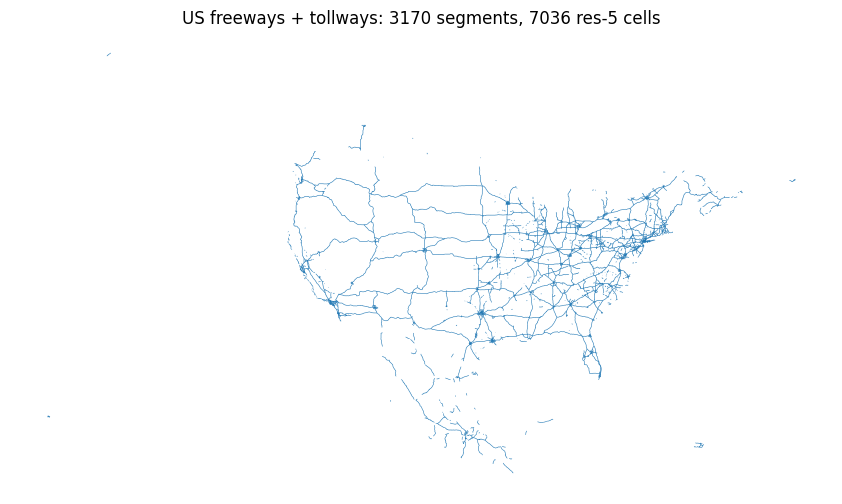

In [14]:
# eyeball the network
ax = gpd.GeoSeries(gdf.geometry, crs=4326).plot(linewidth=0.4, figsize=(11, 6))
ax.set_title(f"US freeways + tollways: {len(gdf)} segments, {len(cells)} res-{RES} cells")
ax.set_axis_off()